# Задание 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

In [2]:
df = pd.read_csv("Electronic_sales_Sep2023-Sep2024.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [4]:
df.shape

(20000, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  str    
 3   Loyalty Member     20000 non-null  str    
 4   Product Type       20000 non-null  str    
 5   SKU                20000 non-null  str    
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  str    
 8   Payment Method     20000 non-null  str    
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  str    
 13  Shipping Type      20000 non-null  str    
 14  Add-ons Purchased  15132 non-null  str    
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4), str(9)
m

In [6]:
df.isna().sum()

Customer ID             0
Age                     0
Gender                  1
Loyalty Member          0
Product Type            0
SKU                     0
Rating                  0
Order Status            0
Payment Method          0
Total Price             0
Unit Price              0
Quantity                0
Purchase Date           0
Shipping Type           0
Add-ons Purchased    4868
Add-on Total            0
dtype: int64

In [7]:
df["Payment Method"].value_counts()

Payment Method
Credit Card      5868
Bank Transfer    3371
PayPal           3284
Paypal           2514
Cash             2492
Debit Card       2471
Name: count, dtype: int64

In [8]:
# Один и тот же метод оплаты записан по-разному
df["Payment Method"] = df["Payment Method"].str.strip().str.title().replace({"Paypal": "PayPal"})

In [9]:
df["order_total"] = df["Total Price"] + df["Add-on Total"]

df[["Customer ID", "Total Price", "Add-on Total", "order_total"]].head()

,Customer ID,Total Price,Add-on Total,order_total
0,1000,5538.33,40.21,5578.54
1,1000,741.09,26.09,767.18
2,1002,1855.84,0.00,1855.84
3,1002,3164.76,60.16,3224.92
4,1003,41.50,35.56,77.06


In [10]:
customer_stats = (
    df
    .groupby("Customer ID")
    .agg(
        total_spent=("order_total", "sum"),
        addons_spent=("Add-on Total", "sum"),
        orders_count=("Customer ID", "count")
    )
    .reset_index()
)

customer_stats.head()

,Customer ID,total_spent,addons_spent,orders_count
0,1000,6345.72,66.30,2
1,1002,5080.76,60.16,2
2,1003,77.06,35.56,1
3,1004,148.78,65.78,1
4,1005,11854.44,75.33,2


In [11]:
payment_counts = (
    df
    .groupby(["Customer ID", "Payment Method"])
    .size()
    .reset_index(name="payments_count")
)

payment_counts.head()

,Customer ID,Payment Method,payments_count
0,1000,Credit Card,1
1,1000,PayPal,1
2,1002,Cash,1
3,1002,Credit Card,1
4,1003,Cash,1


In [12]:
# Применяем лексикографическое правило при ничьей
preferred_payment = (
    payment_counts
    .sort_values(
        ["Customer ID", "payments_count", "Payment Method"],
        ascending=[True, False, True]
    )
    .drop_duplicates(subset="Customer ID", keep="first")
    .rename(columns={"Payment Method": "preferred_payment"})
    [["Customer ID", "preferred_payment"]]
)

preferred_payment.head()

,Customer ID,preferred_payment
0,1000,Credit Card
2,1002,Cash
4,1003,Cash
5,1004,Credit Card
6,1005,Debit Card


In [13]:
customers = customer_stats.merge(
    preferred_payment,
    on="Customer ID",
)

In [14]:
top_customers = (
    customers
    .rename(columns={"Customer ID": "customer_id"})
    [["customer_id", "preferred_payment", "total_spent", "addons_spent", "orders_count"]]
    .round({"total_spent": 2, "addons_spent": 2})
    .sort_values(
        ["total_spent", "customer_id"],
        ascending=[False, True]
    )
    .head(10)
    .reset_index(drop=True)
)

In [15]:
top_customers

,customer_id,preferred_payment,total_spent,addons_spent,orders_count
0,16357,Bank Transfer,35058.89,495.19,7
1,16863,PayPal,33522.09,486.17,5
2,13813,Credit Card,32098.80,268.64,5
3,11476,PayPal,31379.20,301.59,5
4,12276,Bank Transfer,31290.25,329.07,6
5,13635,Credit Card,30741.09,480.73,5
6,12749,Credit Card,30013.99,619.43,5
7,15399,PayPal,29390.27,305.39,3
8,19996,Bank Transfer,27728.90,432.12,6
9,12319,Bank Transfer,27578.70,226.38,3


# Задание 2

In [16]:
df = pd.read_csv("Electronic_sales_Sep2023-Sep2024.csv")

In [17]:
def clean(df) -> pd.DataFrame:
    df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

    df = df[
            (df["Total Price"] > 0) &
            (df["Unit Price"] > 0) &
            (df["Quantity"] > 0) &
            (df["Add-on Total"] >= 0)
        ]

    return df

In [18]:
df = clean(df)

In [27]:
def build_metrics(df) -> dict[str, DataFrame]:
    df["Revenue"] = df["Total Price"] + df["Add-on Total"]
    df["Order Month"] = df["Purchase Date"].dt.to_period("M")
    df["Order Quarter"] = df["Purchase Date"].dt.to_period("Q")
    
    revenue_by_shipping = (
        df.groupby("Shipping Type")
        .agg(revenue=("Revenue", "sum"))
        .sort_values("revenue", ascending=False)
        .reset_index()
    )

    revenue_by_product = (
        df.groupby("Product Type")
        .agg(revenue=("Revenue", "sum"))
        .sort_values("revenue", ascending=False)
        .reset_index()
    )

    months = pd.period_range(df["Order Month"].min(), df["Order Month"].max(), freq="M")
    addons_by_month = (
        df.groupby("Order Month")["Add-on Total"].sum()
        .reindex(months, fill_value=0)
        .rename_axis("month")
        .reset_index(name="addons_revenue")
    )

    quarters = pd.period_range(df["Order Quarter"].min(), df["Order Quarter"].max(), freq="Q")
    addons_by_quarter = (
        df.groupby("Order Quarter")["Add-on Total"].sum()
        .reindex(quarters, fill_value=0)
        .rename_axis("quarter")
        .reset_index(name="addons_revenue")
    )
    
    cohort_df = df.assign(
        cohort=df.groupby("Customer ID")["Order Month"].transform("min")
    )
    cohort_df["month_index"] = (
        (cohort_df["Order Month"].dt.year - cohort_df["cohort"].dt.year) * 12
        + (cohort_df["Order Month"].dt.month - cohort_df["cohort"].dt.month)
    )
    max_month = 3
    cohort_df = cohort_df[cohort_df["month_index"] <= max_month]
    cols = list(range(max_month + 1))

    def to_matrix(values, aggfunc):
        m = cohort_df.pivot_table(index="cohort", columns="month_index", values=values, aggfunc=aggfunc)
        m = m.reindex(columns=cols)
        m.columns.name = None
        # Месяцы, которых ещё нет в данных -> NaN; месяцы без заказов внутри периода -> 0
        cohort_num = m.index.year * 12 + m.index.month
        observable = (cohort_num.values[:, None] + np.array(cols)[None, :]) <= (
            df["Order Month"].max().year * 12 + df["Order Month"].max().month
        )
        return m.fillna(0).where(observable)
        
    return {
        "revenue_by_shipping": revenue_by_shipping,
        "revenue_by_product": revenue_by_product,
        "addons_by_month": addons_by_month,
        "addons_by_quarter": addons_by_quarter,
        "cohort_revenue": to_matrix("Revenue", "sum"),
        "cohort_customers": to_matrix("Customer ID", "nunique"),
    }

In [28]:
metrics = build_metrics(df)

In [29]:
shipping = metrics["revenue_by_shipping"]

In [30]:
shipping

,Shipping Type,revenue
0,Standard,21767205.94
1,Expedited,12709031.67
2,Same Day,12701562.88
3,Overnight,8843861.37
4,Express,8825903.47


In [31]:
product = metrics["revenue_by_product"]

In [32]:
product

,Product Type,revenue
0,Smartphone,21847780.24
1,Smartwatch,14277696.42
2,Laptop,12546265.28
3,Tablet,11968240.83
4,Headphones,4207582.56


In [33]:
addons_month = metrics["addons_by_month"]

In [34]:
addons_month

,month,addons_revenue
0,2023-09,8012.62
1,2023-10,37837.12
2,2023-11,34888.81
3,2023-12,33509.15
4,2024-01,136195.16
5,2024-02,120148.92
6,2024-03,124954.26
7,2024-04,123973.59
8,2024-05,132018.51
9,2024-06,126689.59


In [35]:
metrics["addons_by_quarter"]

,quarter,addons_revenue
0,2023Q3,8012.62
1,2023Q4,106235.08
2,2024Q1,381298.34
3,2024Q2,382681.69
4,2024Q3,366669.23


In [36]:
cohort_rev metrics["cohort_revenue"]

,0,1,2,3
cohort,,,,
2023-09,489974.41,51394.98,48234.13,52196.04
2023-10,2304908.49,158356.48,242545.95,202518.71
2023-11,1896732.34,130987.80,189979.78,99767.21
2023-12,1588479.69,157533.73,107446.70,117115.51
2024-01,6161172.94,575648.64,738396.37,685295.89
2024-02,4834482.41,501142.68,539460.25,618975.30
2024-03,4721928.29,562039.68,498131.11,499682.60
2024-04,4202728.73,405561.06,521178.57,498510.97
2024-05,3948062.29,384732.57,524291.02,354959.10


In [37]:
metrics["cohort_customers"]

,0,1,2,3
cohort,,,,
2023-09,185.0,19.0,19.0,18.0
2023-10,852.0,61.0,77.0,72.0
2023-11,686.0,54.0,63.0,47.0
2023-12,614.0,54.0,45.0,52.0
2024-01,1722.0,163.0,189.0,176.0
2024-02,1386.0,130.0,149.0,155.0
2024-03,1330.0,147.0,145.0,149.0
2024-04,1170.0,120.0,132.0,123.0
2024-05,1097.0,106.0,129.0,104.0


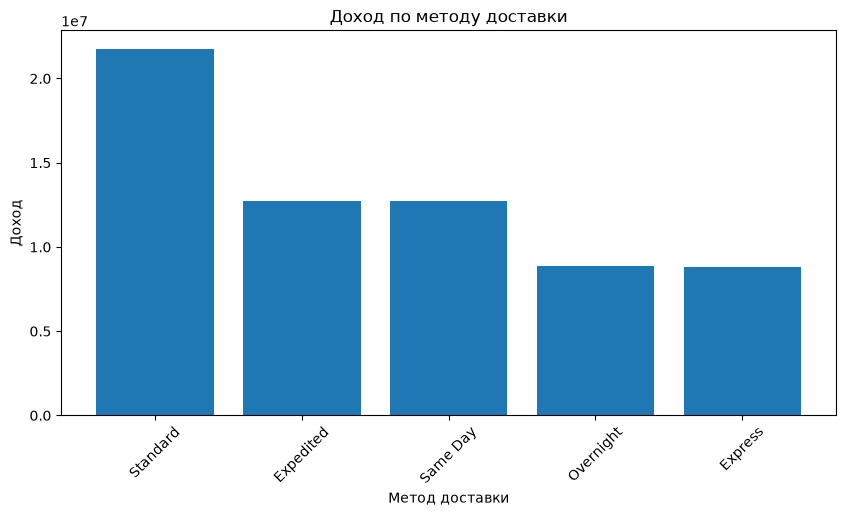

In [41]:
plt.figure(figsize=(10, 5))

plt.bar(
    shipping["Shipping Type"].astype(str),
    shipping["revenue"] 
)

plt.xticks(rotation=45)
plt.title("Доход по методу доставки")
plt.xlabel("Метод доставки")
plt.ylabel("Доход")
plt.show()

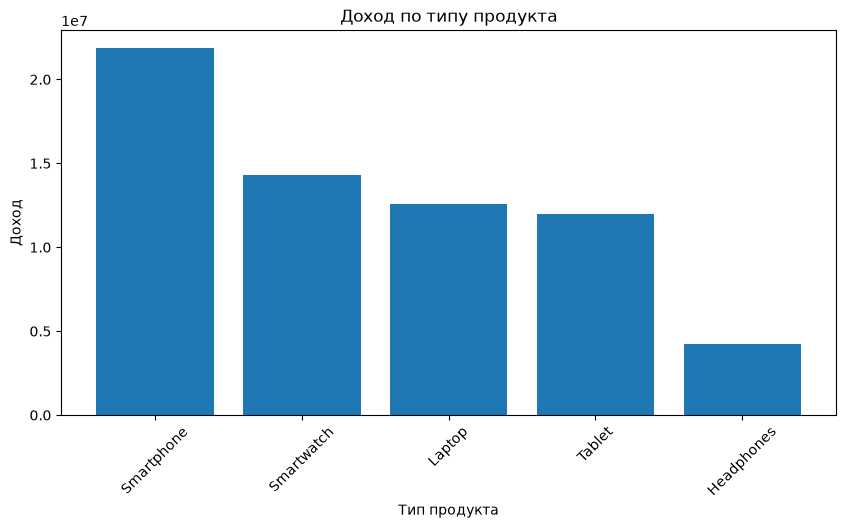

In [42]:
plt.figure(figsize=(10, 5))

plt.bar(
    product["Product Type"],
    product["revenue"] 
)

plt.xticks(rotation=45)
plt.title("Доход от доп. услуг по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Доход")
plt.show()

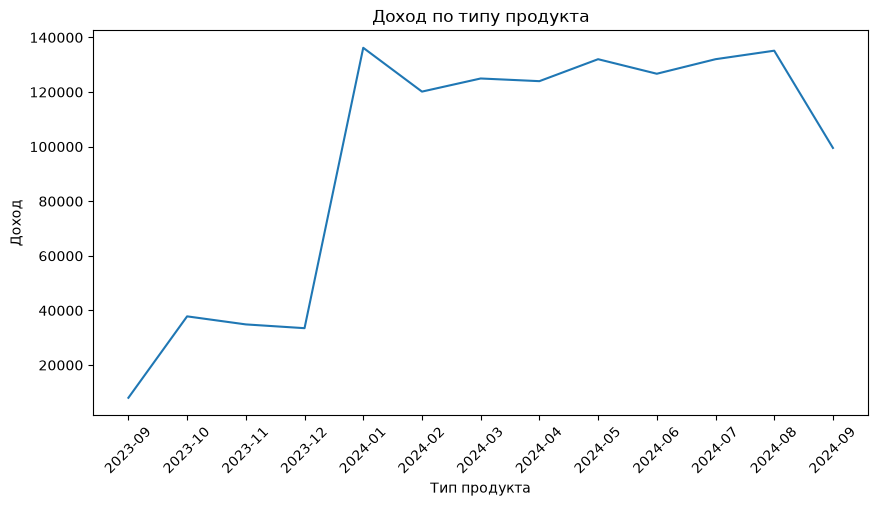

In [45]:
plt.figure(figsize=(10, 5))

plt.plot(
    addons_month["month"].astype(str),
    addons_month["addons_revenue"] 
)

plt.xticks(rotation=45)
plt.title("Доход по типу продукта")
plt.xlabel("Тип продукта")
plt.ylabel("Доход")
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

sns.heatmap(    
    addons_month["month"].astype(str),
    addons_month["addons_revenue"] 
)

plt.xticks(rotation=45)
plt.title("Доход по типу продукта")
plt.xlabel("Тип продукта")
plt.ylabel("Доход")
plt.show()